In [1]:
# Install required libraries (run once)
# pip install pandas numpy matplotlib seaborn wordcloud openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [3]:
# Load the CSV file exported from Instagram or a tool
df = pd.read_csv('comments.csv')

# Preview the data
print(df.shape)       # How many rows and columns
print(df.dtypes)      # Data types of each column
df.head()             # First 5 rows

(7488, 8)
id                      int64
comment                object
User  id                int64
Photo id                int64
created Timestamp      object
posted date            object
emoji used             object
Hashtags used count     int64
dtype: object


,id,comment,User id,Photo id,created Timestamp,posted date,emoji used,Hashtags used count
0,1,unde at dolorem,2,1,13-04-2023 08:04,April 14,yes,1
1,2,quae ea ducimus,3,1,13-04-2023 08:04,April 14,no,2
2,3,alias a voluptatum,5,1,13-04-2023 08:04,April 14,no,4
3,4,facere suscipit sunt,14,1,13-04-2023 08:04,April 14,yes,2
4,5,totam eligendi quaerat,17,1,13-04-2023 08:04,April 14,yes,1


In [6]:
# Convert 'created Timestamp' to proper datetime format
df['created Timestamp'] = pd.to_datetime(df['created Timestamp'], format='%d-%m-%Y %H:%M')

# Extract useful time parts from 'created Timestamp'
df['hour']        = df['created Timestamp'].dt.hour        # 0-23
df['day_of_week'] = df['created Timestamp'].dt.day_name() # Monday, Tuesday...
df['month']       = df['created Timestamp'].dt.month_name()
df['week']        = df['created Timestamp'].dt.isocalendar().week

# The original code attempted to fill missing values or filter by 'likes', 'comments', 'hashtags', and 'followers'.
# These columns were not found in the current DataFrame.
# If you intend to use these, please ensure your CSV file contains them or their equivalents.
# For example, 'Hashtags used count' already exists as an integer column.

print("Data cleaning applied to 'created Timestamp' column and time features extracted. Total posts:", len(df))

Data cleaning applied to 'created Timestamp' column and time features extracted. Total posts: 7488


In [8]:
# The original code attempted to calculate engagement metrics using 'likes', 'comments', and 'followers' columns.
# These columns were not found in the current DataFrame.
# If you have these metrics, please ensure your CSV file contains them or their equivalents.
# You currently have 'comment' (the text itself) and 'Hashtags used count'.

print("Engagement metric calculations skipped due to missing columns: 'likes', 'comments', 'followers'.")

Engagement metric calculations skipped due to missing columns: 'likes', 'comments', 'followers'.


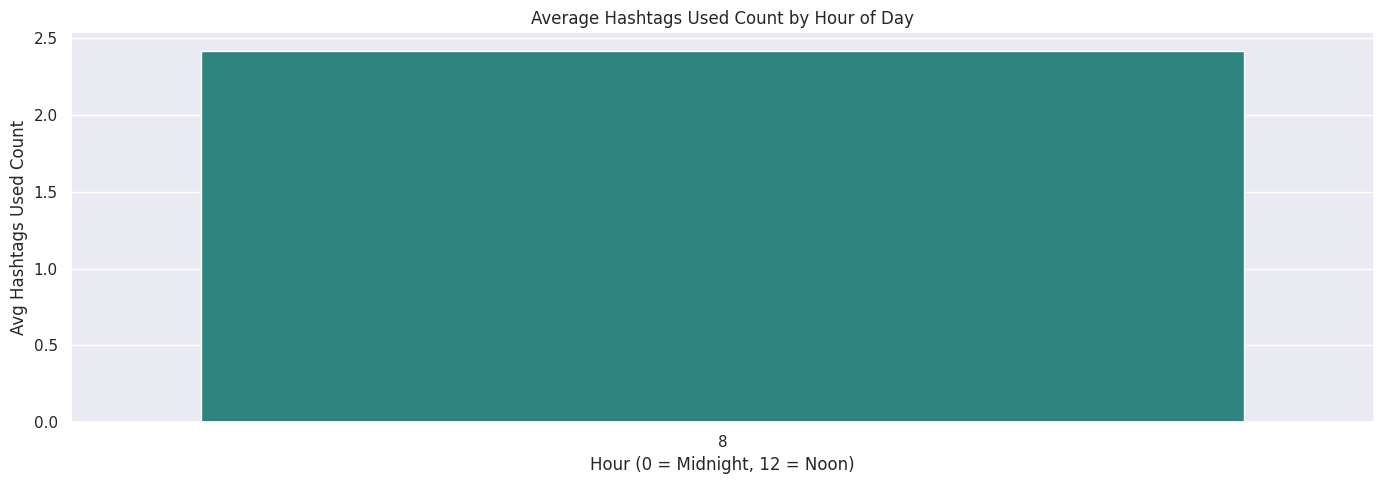

In [10]:
# Average 'Hashtags used count' by hour as an alternative engagement metric
hourly_hashtags = df.groupby('hour')['Hashtags used count'].mean().reset_index()

plt.figure(figsize=(14, 5))
sns.barplot(data=hourly_hashtags, x='hour', y='Hashtags used count', palette='viridis')
plt.title('Average Hashtags Used Count by Hour of Day')
plt.xlabel('Hour (0 = Midnight, 12 = Noon)')
plt.ylabel('Avg Hashtags Used Count')
plt.tight_layout()
plt.savefig('best_hours_hashtags.png', dpi=150)
plt.show()

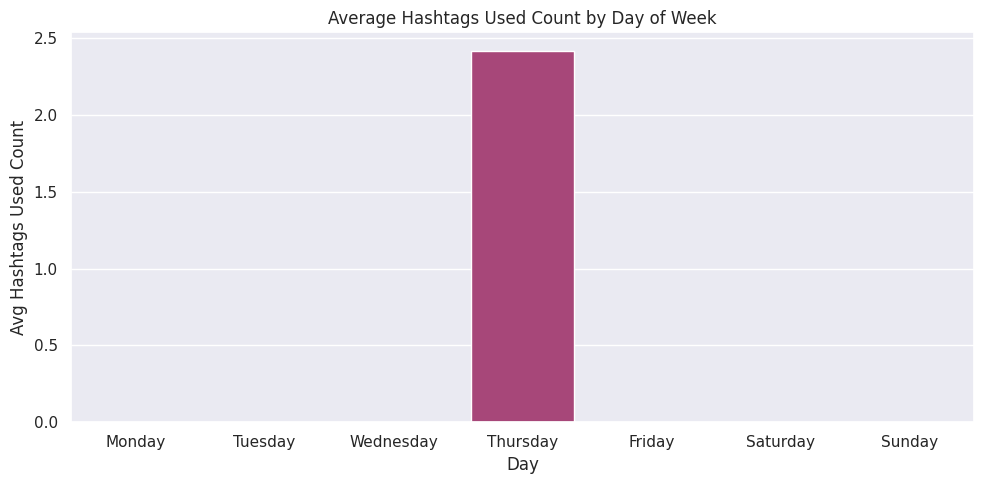

In [12]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# Use 'Hashtags used count' as an alternative engagement metric
daily = df.groupby('day_of_week')['Hashtags used count'].mean().reindex(day_order).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=daily, x='day_of_week', y='Hashtags used count', palette='magma')
plt.title('Average Hashtags Used Count by Day of Week')
plt.xlabel('Day')
plt.ylabel('Avg Hashtags Used Count')
plt.tight_layout()
plt.savefig('best_days_hashtags.png', dpi=150)
plt.show()

  emoji used  avg_hashtags  total_posts
0         no      3.666667         3744
1        yes      1.166667         3744


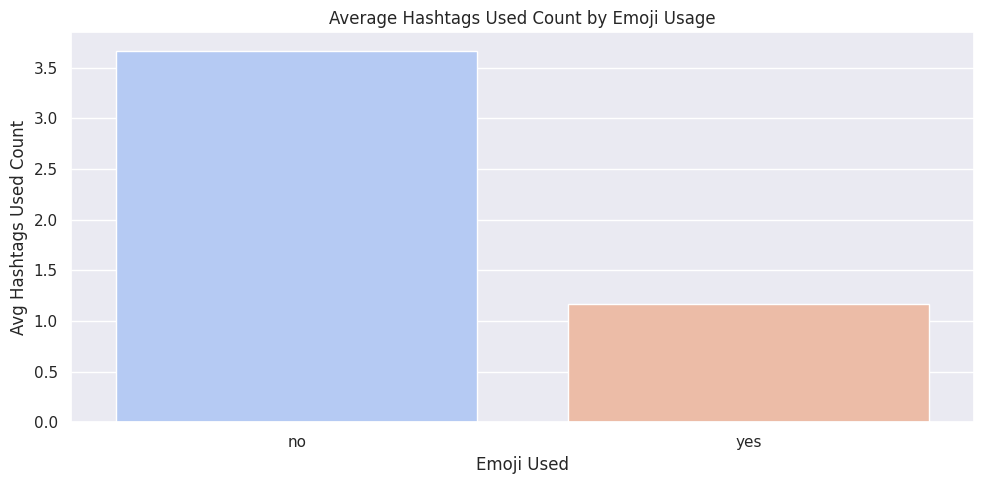

In [14]:
# Compare posts with emojis vs. without emojis as an alternative content grouping
content = df.groupby('emoji used').agg(
    avg_hashtags=('Hashtags used count', 'mean'),
    total_posts=('id', 'count')
).reset_index()

print(content)

# Bar chart
plt.figure(figsize=(10, 5))
sns.barplot(data=content, x='emoji used', y='avg_hashtags', palette='coolwarm')
plt.title('Average Hashtags Used Count by Emoji Usage')
plt.xlabel('Emoji Used')
plt.ylabel('Avg Hashtags Used Count')
plt.tight_layout()
plt.savefig('emoji_usage.png', dpi=150)
plt.show()

In [16]:
import re
from collections import Counter

# Function to extract hashtags from text
def extract_hashtags(text):
    if isinstance(text, str):
        return re.findall(r'#\w+', text)
    return []

# Apply the function to the 'comment' column to get a list of hashtags for each comment
df['extracted_hashtags'] = df['comment'].apply(extract_hashtags)

# Combine all extracted hashtags into one long string
# Flatten the list of lists and join them with spaces
all_tags = ' '.join([tag for sublist in df['extracted_hashtags'].tolist() for tag in sublist])

# Check if all_tags is empty before proceeding
if not all_tags:
    print("No hashtags found in the 'comment' column. Cannot generate top tags or word cloud.")
else:
    # Count frequency of each hashtag
    tag_list = all_tags.split()
    tag_freq = Counter(tag_list)
    top_tags = pd.DataFrame(tag_freq.most_common(20), columns=['hashtag', 'count'])
    print(top_tags)

    # Word Cloud
    wordcloud = WordCloud(width=1200, height=600,
                          background_color='black',
                          colormap='cool').generate(all_tags)

    plt.figure(figsize=(14, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Most Used Hashtags', fontsize=18)
    plt.tight_layout()
    plt.savefig('hashtags_wordcloud.png', dpi=150)
    plt.show()

No hashtags found in the 'comment' column. Cannot generate top tags or word cloud.


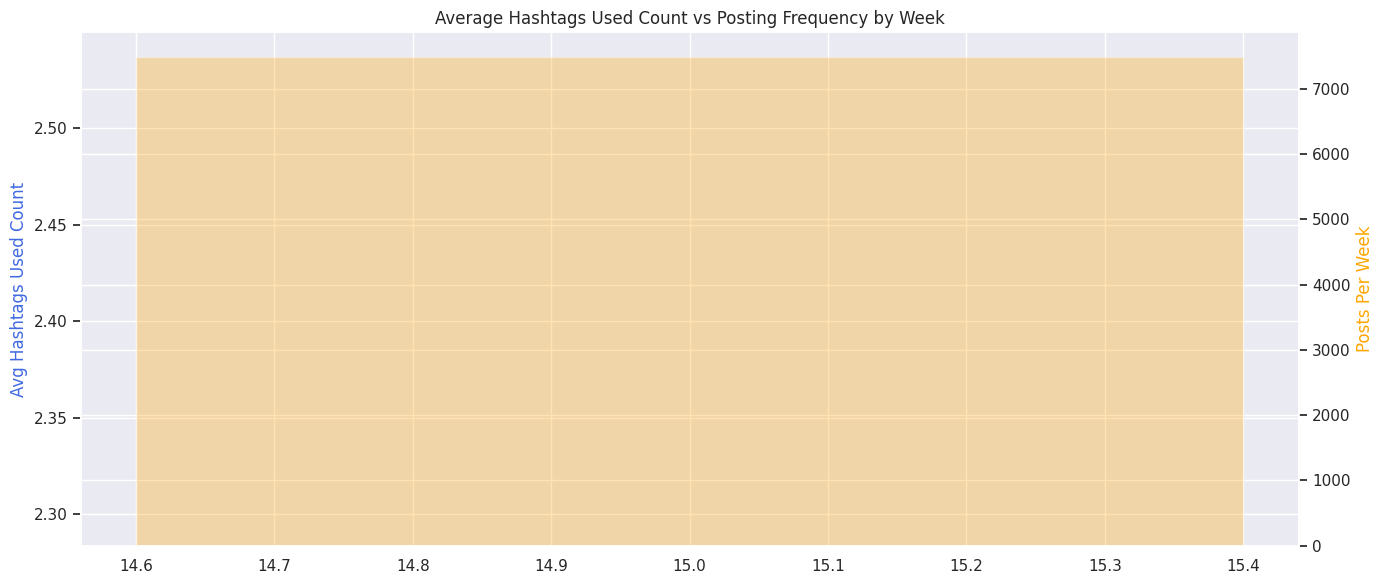

In [18]:
# Sort by date and compute weekly averages
df_sorted = df.sort_values('created Timestamp')
weekly = df_sorted.groupby('week').agg(
    avg_hashtags=('Hashtags used count', 'mean'),
    post_count=('id', 'count')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(weekly['week'], weekly['avg_hashtags'], color='royalblue', label='Avg Hashtags Used')
ax1.set_ylabel('Avg Hashtags Used Count', color='royalblue')

ax2 = ax1.twinx()
ax2.bar(weekly['week'], weekly['post_count'], alpha=0.3, color='orange', label='Posts/Week')
ax2.set_ylabel('Posts Per Week', color='orange')

plt.title('Average Hashtags Used Count vs Posting Frequency by Week')
fig.tight_layout()
plt.savefig('weekly_hashtags_posts.png', dpi=150)
plt.show()

In [20]:
# Summarize findings for the strategy doc
best_hour = hourly_hashtags.loc[hourly_hashtags['Hashtags used count'].idxmax(), 'hour']
best_day  = daily.loc[daily['Hashtags used count'].idxmax(), 'day_of_week']
best_type = content.loc[content['avg_hashtags'].idxmax(), 'emoji used']
avg_hashtags_overall = df['Hashtags used count'].mean()

# Top hashtags cannot be determined as no hashtags were found in the 'comment' column.
top_hashtags_summary = "N/A (no hashtags found in comments)"

print(f"""
=== ALFIDO TECH INSTAGRAM STRATEGY SUMMARY ===

📅 Best Day to Post   : {best_day}
🕐 Best Hour to Post  : {best_hour}:00
📸 Best Content Type  : {'Posts with ' + best_type + ' emojis'}
📊 Avg Hashtags Used: {avg_hashtags_overall:.2f}
🏷️  Top Hashtags       : {top_hashtags_summary}
""")


=== ALFIDO TECH INSTAGRAM STRATEGY SUMMARY ===

📅 Best Day to Post   : Thursday
🕐 Best Hour to Post  : 8:00
📸 Best Content Type  : Posts with no emojis
📊 Avg Hashtags Used: 2.42
🏷️  Top Hashtags       : N/A (no hashtags found in comments)

